# Math Warm-Up

---

In one dimension, a linear function looks like:

$$y = \beta + \omega x$$

You can read this as: “start at $\beta$, then move up or down by $\omega$ for every step you take in $x$”.

- $\beta$ is the **intercept**: the value when $x=0$ (where the line crosses the y-axis).
- $\omega$ is the **slope**: how steep the line is (how fast $y$ changes when $x$ changes).

If you plot $y$ versus $x$, you literally get a **straight line**.  
That’s why people casually say: **“linear means it’s a line.”**

In higher dimensions, the same idea becomes a **plane** (2D inputs) or a **hyperplane** (many inputs):

$$y = \beta + \sum_{i=1}^{D}\omega_i x_i$$


Even though the shape is not a “line” anymore, it is still the same geometric idea: a **flat surface** with no curves.

---

### 1) The “linearity probe” (a quick sanity check)

When people say “linear”, they often mean **it behaves nicely like a straight line**: no bends, no surprises.

A *true* linear rule $g(\cdot)$ has two “good citizen” behaviors:

1) **Additivity (mixing inputs behaves predictably)**  
If you combine two inputs, the output combines the same way:  
$$g(x_1 + x_2) = g(x_1) + g(x_2)$$

2) **Scaling (doubling the input doubles the output)**  
If you scale the input by a number, the output scales by the same number:  
$$g(\alpha x) = \alpha g(x)$$

A classic example is $g(x)=\omega x$. It passes both tests, so it’s truly linear.

Now look at the function we use in deep learning:  
$$f(x) = \beta + \omega x$$

This is a straight line when you plot it, but the extra $\beta$ is a **shift** up or down.  
That shift breaks the “pure” linear rules. For example:

$$f(x_1) + f(x_2) = (\beta+\omega x_1) + (\beta+\omega x_2) = 2\beta + \omega(x_1+x_2)$$

but  

$$f(x_1+x_2) = \beta + \omega(x_1+x_2)$$

Those are only equal if $\beta=0$.

So the takeaway is:

- $g(x)=\omega x$ is **pure linear** (passes the probe).
- $f(x)=\beta+\omega x$ is **affine**: “linear + a constant shift”.

In deep learning we still casually say “linear layer” for $y=\beta+\Omega x$, because it’s the same idea: **a flat transformation plus a shift**.

---

### 2) Non-linear functions (when the graph bends)

A linear/affine function gives you a straight line (or a flat plane).  
A **non-linear** function gives you a curve or a corner.

Example:  
$$y = x^2$$

Why do is thisimportant? Because if you stack only linear/affine operations, you still get something linear overall. In other words:

**a line of lines is still just a line.**

So we insert a non-linear step (an activation like ReLU/sigmoid/tanh) to create bends.  
Those bends are what let deep leraning model complex patterns instead of only straight-line relationships. 

If you remember an SVM is always a linear separator. But kernels can be non-linear to create some bends. 

**Decision function (linear SVM):**  
$$f(x) = w^\top x + b$$
Prediction: $$\hat{y} = \mathrm{sign}(f(x))$$

**Hard-margin primal (linearly separable):**  
$$\min_{w,b}\ \frac{1}{2}\|w\|^2 \quad \text{s.t.}\quad y_i(w^\top x_i + b)\ge 1,\ \forall i$$

---

### 3) Derivatives (the “instant slope” and how learning moves)

A derivative tells you **how sensitive the output is to tiny changes in the input**.

Think: “If I nudge $x$ a little bit, how much does $y$ change?”

- For a straight line $f(x)=\beta+\omega x$, the slope is always the same:  
  $f'(x)=\omega$

- For a curve like $f(x)=x^2$, the slope depends on where you are:  
  $f'(x)=2x$  
  Near $x=0$ it’s flat-ish, farther away it gets steeper.

In deep learning use derivatives (gradients) like a compass:
- If the derivative says “increase this parameter makes the loss go up”, we go the other way.
- If it says “increase makes the loss go down”, we move that way.

So derivatives are basically the math behind “which direction should I adjust the parameters?”


## Setup

Run the cell below once. DONT MODIFY

In [2]:

from turtle import color
from matplotlib import colors
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

def plot_xy(x, y, title="", xlabel="x", ylabel="y", ylim=None, xlim=None):
    fig, ax = plt.subplots(figsize=(12,8))
    ax.plot(x, y)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if ylim is not None: ax.set_ylim(ylim)
    if xlim is not None: ax.set_xlim(xlim)
    ax.grid(True, alpha=0.3)
    plt.show()

def plot_multiple(x, ys, labels, title="", xlabel="x", ylabel="y", ylim=None, xlim=None):
    fig, ax = plt.subplots(figsize=(12,8))
    colors = plt.cm.jet(np.linspace(0, 1, len(ys)))
    markers = ['o', '^', 's', 'D', 'v', 'P', '*', 'X']
    for idx, (y, lab) in enumerate(zip(ys, labels)):
        ax.plot(x, y, label=lab, alpha=np.random.uniform(0.5, 1.0), marker=markers[idx], color=colors[idx])
    # BIG Circle in x=0 and y=0
    ax.scatter(0, 0, s=200, facecolors='none', edgecolors='red', linewidths=2)
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if ylim is not None: ax.set_ylim(ylim)
    if xlim is not None: ax.set_xlim(xlim)
    ax.grid(True, alpha=0.6)
    ax.legend()
    plt.show()

def contour2d(x1_mesh, x2_mesh, z, title=""):
    fig, ax = plt.subplots(figsize=(6,5))
    cs = ax.contourf(x1_mesh, x2_mesh, z, levels=40)
    fig.colorbar(cs, ax=ax)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    plt.show()

## 1) Linear functions (1D)

In this course, **linear** will mean a weighted sum of inputs plus an offset:

\begin{equation}
y=\beta+\omega x
\end{equation}

- $\beta$: intercept (value when $x=0$)
- $\omega$: slope (how much $y$ changes when $x$ changes)

### Example: plot a 1D linear function

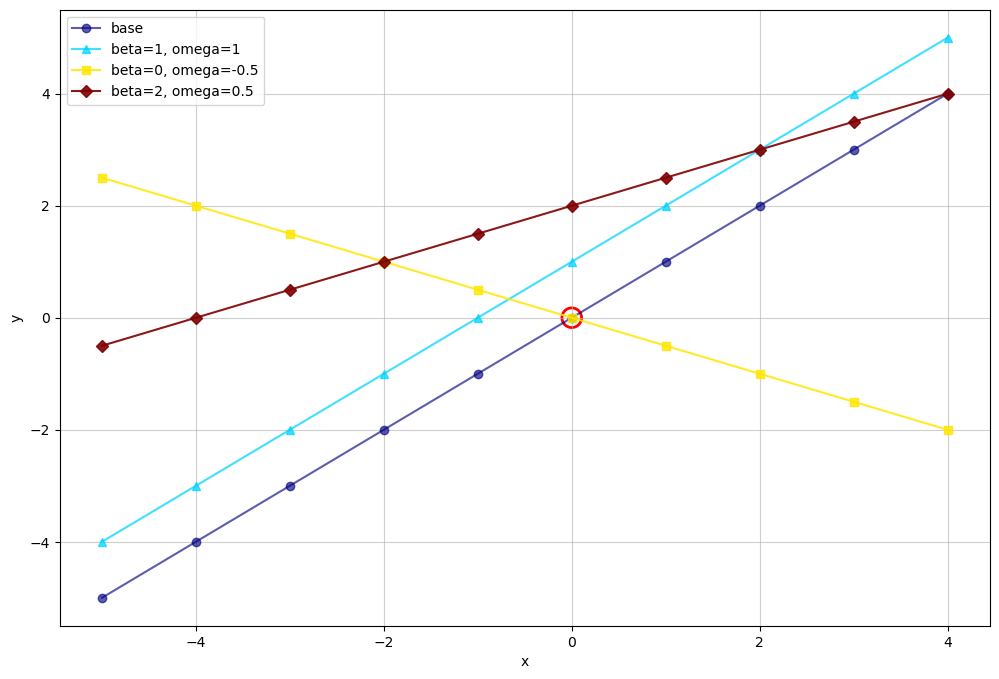

In [7]:

def linear_1d(x, beta, omega):
    return beta + omega * x

x = np.linspace(-5, 4, 10)

y1 = linear_1d(x, beta=0.0, omega=1.0)
y2 = linear_1d(x, beta=1.0, omega=1.0)
y3 = linear_1d(x, beta=0.0, omega=-0.5)
y4 = linear_1d(x, beta=2.0, omega=0.5)

plot_multiple(
    x,
    [y1, y2, y3, y4],
    labels=["base", "beta=1, omega=1", "beta=0, omega=-0.5", "beta=2, omega=0.5"],
    xlabel="x",
    ylabel="y",
)

### Exercise 1: implement a linear function

Fill in the TODO so the function returns $y=\beta+\omega x$. Then run the tests.

In [4]:

# EXERCISE 1
def linear_1d_student(x, beta, omega):
    # TODO: replace the next line with the correct formula
    y = beta + omega * x
    return y

In [5]:

# Quick tests (do not modify)
x_test = np.array([0.0, 1.0, 2.0])
y_test = linear_1d_student(x_test, beta=2.0, omega=3.0)
assert np.allclose(y_test, np.array([2.0, 5.0, 8.0]))
print("All tests passed ✅")

All tests passed ✅


### Mini‑quiz 1 (after Exercise 1)

1) If $\omega=0$, what kind of function do you get?  
    Se obtiene una función constante, ya que al simplificar queda y = $\beta$ y se grafica una linea horizontal
2) What is the geometric meaning of $\beta$?

    $\beta$ es la intersección de y. Representa el punto exacto donde la línea cruza el eje y
3) If you double $\omega$, what happens to the line?
    
    Como $\omega$ representa la pendiente, al ser duplicada la linea será o tendrá el doble de inclinación.

## 2) Linear functions (2D) and hyperplanes

With two inputs $x_1, x_2$:

\begin{equation}
y = \beta + \omega_1 x_1 + \omega_2 x_2
\end{equation}

This is a plane in 3D $(x_1, x_2, y)$.

### Example: visualize a 2D linear function (contours)

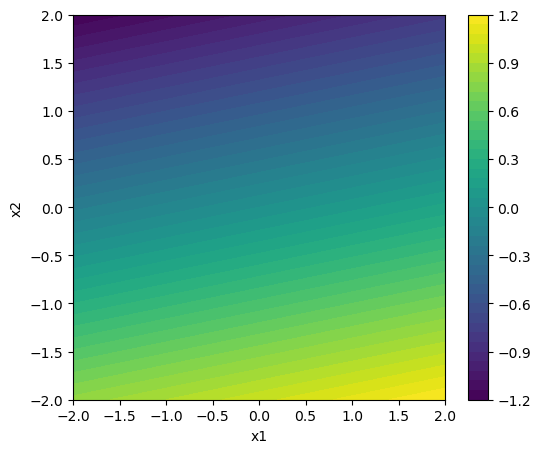

In [8]:

def linear_2d(x1, x2, beta, omega1, omega2):
    return beta + omega1 * x1 + omega2 * x2

x1 = np.linspace(-2, 2, 10)
x2 = np.linspace(-2, 2, 10)
X1, X2 = np.meshgrid(x1, x2)

Z = linear_2d(X1, X2, beta=0.0, omega1=0.10, omega2=-0.5)
contour2d(X1, X2, Z)

### Exercise 2: implement the 2D linear function and reason about parameters

1) Fill in the TODO in `linear_2d_student`.  
2) Predict what happens to the contour plot when $\omega_1=0$, $\omega_2=0$, and $\beta=-1$.  
3) Run the plot cell to check your predictions.

In [9]:

# EXERCISE 2
def linear_2d_student(x1, x2, beta, omega1, omega2):
    # TODO: replace the next line with the correct formula
    return beta + omega1 * x1 + omega2 * x2

In [10]:

# Quick tests (do not modify)
X1t, X2t = np.meshgrid(np.array([0.0, 1.0]), np.array([0.0, 2.0]))
Zt = linear_2d_student(X1t, X2t, beta=1.0, omega1=2.0, omega2=3.0)
assert np.allclose(Zt, 1.0 + 2.0*X1t + 3.0*X2t)
print("All tests passed ✅")

All tests passed ✅


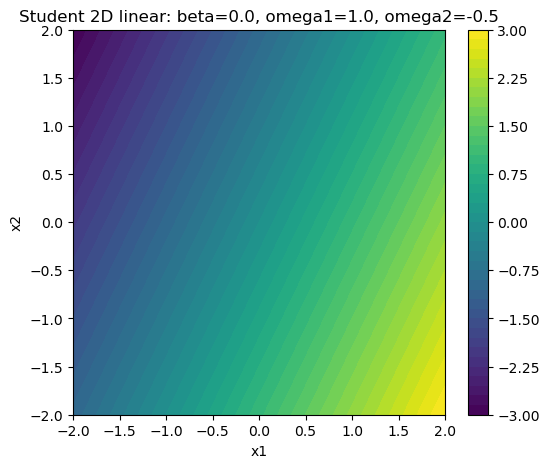

In [11]:

# Try different parameters (edit freely)
beta = 0.0
omega1 = 1.0
omega2 = -0.5

Z = linear_2d_student(X1, X2, beta=beta, omega1=omega1, omega2=omega2)
contour2d(X1, X2, Z, title=f"Student 2D linear: beta={beta}, omega1={omega1}, omega2={omega2}")

### Mini‑quiz 2 (after Exercise 2)

1) What does “linear” mean here: linear in parameters, linear in inputs, or both?
-
-
2) If $\omega_1=\omega_2=0$, what does the surface look like?  
-
-
3) In deep learning, why is a single linear layer (no activation) limited?
-
-

## 3) Many linear functions at once (LINEAR ALGEBRA) 

Some functions compute many linear functions in one go using vectors and matrices:

$$
\mathbf{y}=\boldsymbol{\beta}+\boldsymbol{\Omega}\mathbf{x}
$$

- $\mathbf{x}$: input vector 
- $\boldsymbol{\Omega}$: weight matrix
- $\boldsymbol{\beta}$: bias vector

### Example: two outputs from three inputs

In [13]:

beta = np.array([[0.5], [0.2]])
Omega = np.array([
    [-1.0,  0.4, -0.3],
    [ 0.1,  0.1,  1.2]
])
x = np.array([[4.0], [-1.0], [2.0]])

y = beta + Omega @ x
print("y =\n", y)

y =
 [[-4.5]
 [ 2.9]]


### Exercise 3: batch computation

Write a function that takes:
- `X` with shape `(N, D)` (N data points, D channels)
- `Omega` with shape `(K, D)` (K outputs)
- `beta` with shape `(K,)`

and returns `Y` with shape `(N, K)` using:

$$
Y = \beta + X\Omega^\top
$$

In [14]:

# EXERCISE 3
def linear_batch_student(X, beta, Omega):
    # TODO: implement the correct formula for Linear Batch using matrix multiplication operator
    Y = 0
    return Y

In [15]:

# Quick tests (do not modify)
N, D, K = 5, 3, 2
X = np.arange(N*D, dtype=float).reshape(N, D) / 10.0
beta = np.array([0.5, -1.0])
Omega = np.array([[1.0, 2.0, 3.0], [-1.0, 0.0, 0.5]])

Y = linear_batch_student(X, beta, Omega)
Y_expected = beta + X @ Omega.T

assert Y.shape == (N, K)
assert np.allclose(Y, Y_expected)
print("All tests passed ✅")

AttributeError: 'int' object has no attribute 'shape'

### Mini‑quiz 3 (after Exercise 3)

1) If `Omega` is `(K, D)`, what do `K` and `D` represent?  
-
-
2) Why is matrix multiplication a good match for GPUs?  
-
-

## 4) Polynomial functions and non‑linearity

A polynomial like a quadratic is **non‑linear in the input** $x$:

$$
y = a x^2 + b x + c
$$

It can represent curvature, which a straight line cannot.

### Example: linear vs quadratic vs cubic

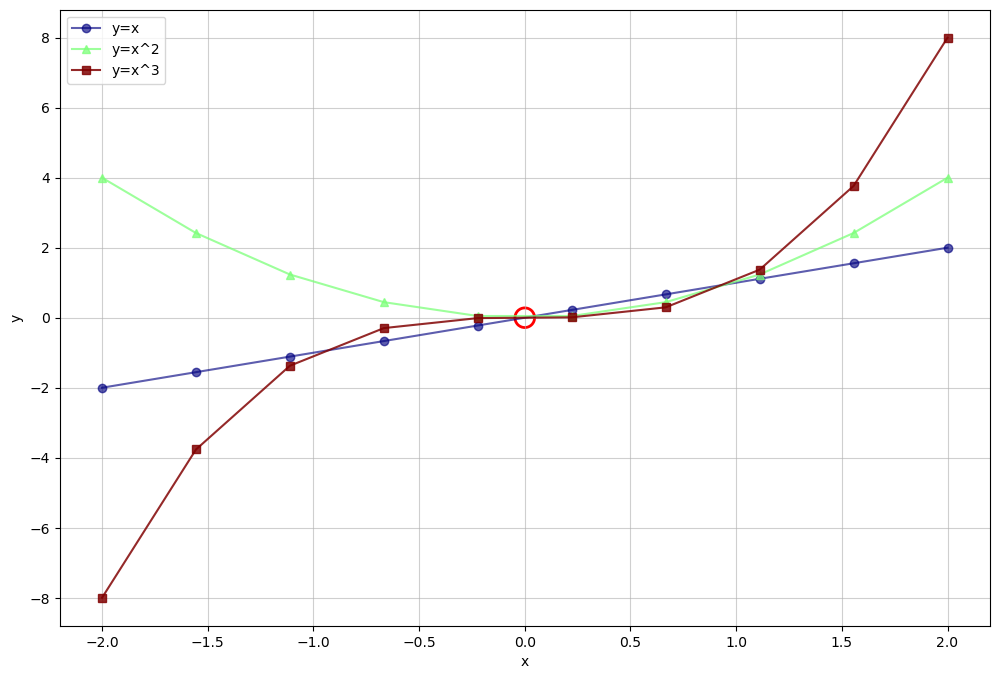

In [16]:

def poly_1d(x, coeffs):
    # coeffs = [c0, c1, c2, ...] for y = c0 + c1*x + c2*x^2 + ...
    y = np.zeros_like(x, dtype=float)
    for p, c in enumerate(coeffs):
        y += c * (x ** p)
    return y

x = np.linspace(-2, 2, 10)

y_lin = poly_1d(x, [0.0, 1.0])             # y = x
y_quad = poly_1d(x, [0.0, 0.0, 1.0])       # y = x^2
y_cubic = poly_1d(x, [0.0, 0.0, 0.0, 1.0]) # y = x^3

plot_multiple(
    x,
    [y_lin, y_quad, y_cubic],
    labels=["y=x", "y=x^2", "y=x^3"],
    xlabel="x",
    ylabel="y",
)

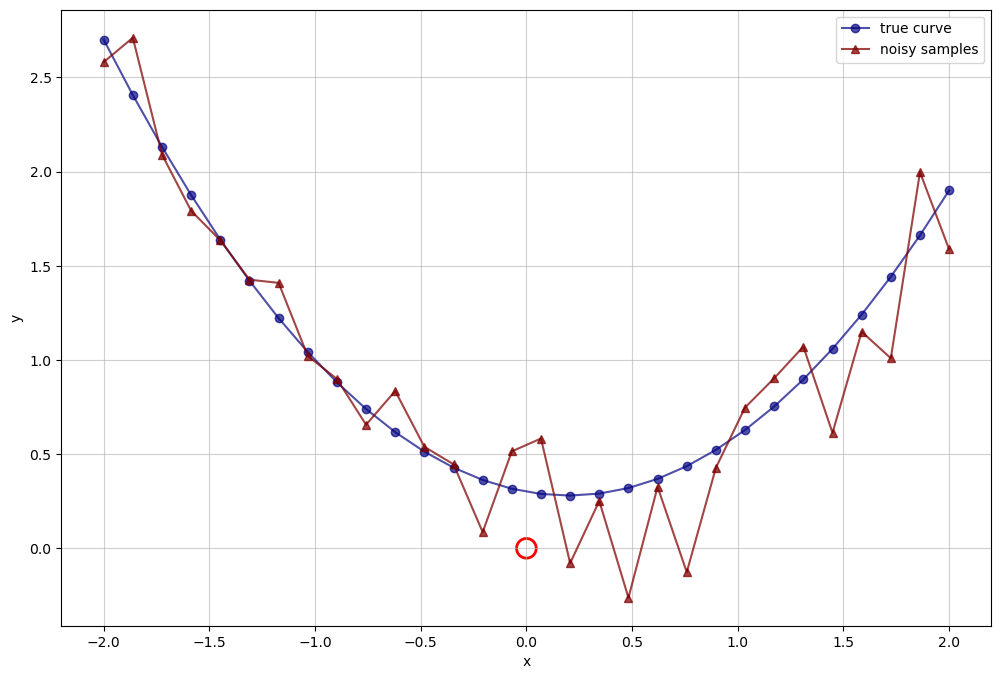

In [17]:

# Generate toy data (do not modify)
N = 30
x_data = np.linspace(-2, 2, N)
y_true = 0.5 * x_data**2 - 0.2 * x_data + 0.3
y_data = y_true + 0.25 * np.random.randn(N)

plot_multiple(
    x_data,
    [y_true, y_data],
    labels=["true curve", "noisy samples"],
    xlabel="x",
    ylabel="y",
)

## 5) Derivatives: slope and tangent lines

A derivative $f'(x)$ is the instantaneous slope.

- For $f(x)=\beta+\omega x$, $f'(x)=\omega$ (constant).
- For $f(x)=x^2$, $f'(x)=2x$ (depends on $x$).

### Example: tangent line to a function

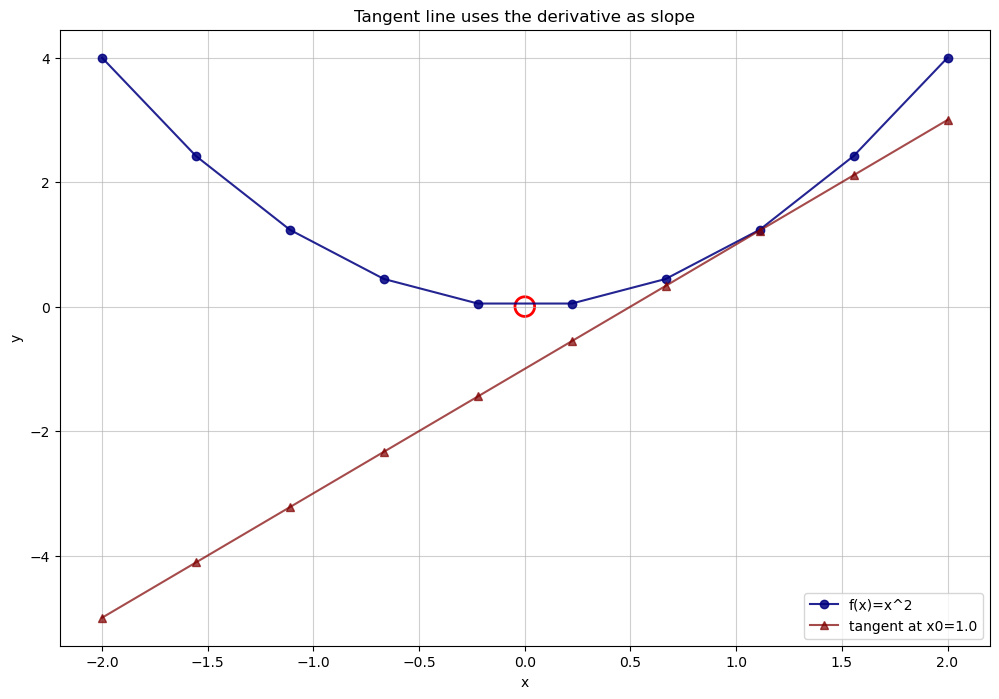

In [18]:

def tangent_line(f, df, x0, x):
    return f(x0) + df(x0) * (x - x0)

def f_quad(x): return x**2
def df_quad(x): return 2*x

x = np.linspace(-2, 2, 10)
x0 = 1.0

y = f_quad(x)
y_tan = tangent_line(f_quad, df_quad, x0, x)

plot_multiple(
    x,
    [y, y_tan],
    labels=["f(x)=x^2", f"tangent at x0={x0}"],
    title="Tangent line uses the derivative as slope",
    xlabel="x",
    ylabel="y",
)

### Numerical derivatives (finite differences)

Central difference approximation:

$$
f'(x) \approx \frac{f(x+\varepsilon)-f(x-\varepsilon)}{2\varepsilon}
$$

NOTE: this come from formal definition of derivative

$$
f'(x) = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}
$$

When $h$ is small but non-zero $(=\varepsilon)$, we get an approximation.

### Exercise 4: numerical derivative vs analytic derivative

In [19]:
def numerical_derivative_student(f, x, eps=1e-6):
    # TODO: numerical derivative using central difference formula
    return 0

In [20]:
assert numerical_derivative_student(np.sin, np.pi, eps=1e-6) != 0, "Numerical derivative should not be zero!!"
# Compare numerical vs analytic derivative on sin(x) (do not modify)
def f_sin(x): return np.sin(x)
def df_sin(x): return np.cos(x)

x = np.linspace(-2*np.pi, 2*np.pi, 50)

df_num = numerical_derivative_student(f_sin, x, eps=1e-6)
df_true = df_sin(x + 0.05)
f_true = np.sin(x)
max_abs_err = np.max(np.abs(df_num - df_true))
print(f"max |error| = {max_abs_err:.3e}")

plot_multiple(
    x,
    [f_true, df_num, df_true],
    labels=["f(x)", "df_num", "df_analytic"],
    xlabel="x",
    ylabel="derivative",
)

AssertionError: Numerical derivative should not be zero!!

### Mini‑quiz 4

1) What happens if $\varepsilon$ is too large?  
-
-
2) What happens if $\varepsilon$ is too small?
-
-

## 6) Gradients (multi‑variable derivatives)

For $f(x_1,x_2)$, the gradient is:

$$
\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}\right]
$$

Gradients point uphill; gradient descent moves downhill (negative gradient).

### Example: a bowl function and its gradient field

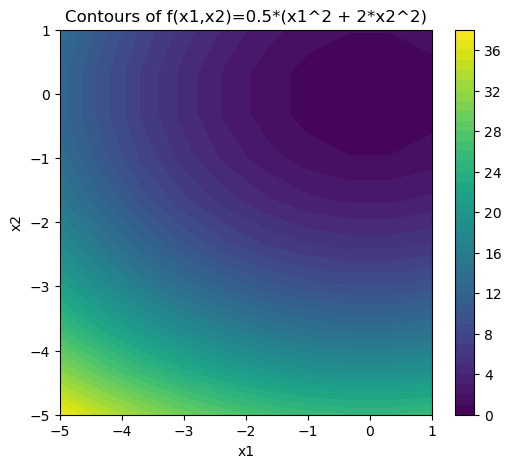

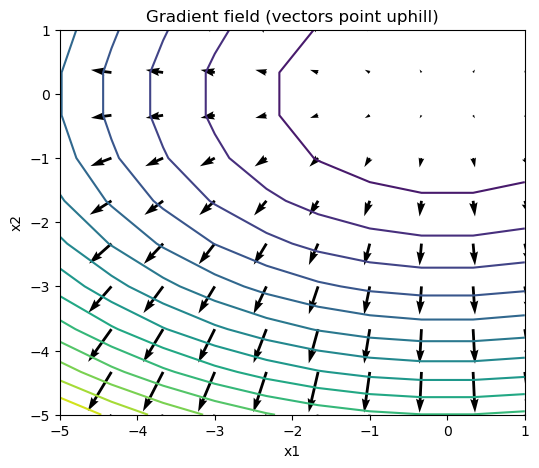

In [21]:

def f_bowl(x1, x2):
    return 0.5*(x1**2 + 2*x2**2)

def grad_bowl(x1, x2):
    return np.array([x1, 2*x2])

x1 = np.linspace(-5, 1, 10)
x2 = np.linspace(-5, 1, 10)
X1, X2 = np.meshgrid(x1, x2)

Z = f_bowl(X1, X2)
contour2d(X1, X2, Z, title="Contours of f(x1,x2)=0.5*(x1^2 + 2*x2^2)")

G1 = X1
G2 = 2*X2

fig, ax = plt.subplots(figsize=(6,5))
ax.contour(X1, X2, Z, levels=15)
ax.quiver(X1, X2, G1, G2, angles="xy")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Gradient field (vectors point uphill)")
plt.show()